# EfficientNet V2 Training 

In [11]:
!pip install timm grad-cam kagglehub -q

In [40]:
import os
import torch
import timm
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    confusion_matrix,
    classification_report
)

from tqdm import tqdm


In [13]:
import kagglehub

path = kagglehub.dataset_download(
    "sovitrath/diabetic-retinopathy-224x224-2019-data"
)

print("Dataset Path:", path)

Dataset Path: C:\Users\Asus\.cache\kagglehub\datasets\sovitrath\diabetic-retinopathy-224x224-2019-data\versions\4


In [14]:
os.makedirs("outputs", exist_ok=True)

os.makedirs(
    "outputs/gradcam/correct",
    exist_ok=True
)

os.makedirs(
    "outputs/gradcam/wrong",
    exist_ok=True
)


In [15]:
dataset_path = path + "/colored_images"

output_path = "/content/retinopathy_split"

classes = [
    'Mild',
    'Moderate',
    'No_DR',
    'Proliferate_DR',
    'Severe'
]

print("Classes:", classes)

Classes: ['Mild', 'Moderate', 'No_DR', 'Proliferate_DR', 'Severe']


In [19]:
import shutil
import os

if os.path.exists("/content/retinopathy_split"):
    shutil.rmtree("/content/retinopathy_split")

print("Old split folder removed")

Old split folder removed


In [20]:
for cls in classes:

    os.makedirs(
        f"{output_path}/train/{cls}",
        exist_ok=True
    )

    os.makedirs(
        f"{output_path}/val/{cls}",
        exist_ok=True
    )

    os.makedirs(
        f"{output_path}/test/{cls}",
        exist_ok=True
    )

    images = os.listdir(
        f"{dataset_path}/{cls}"
    )

    train_imgs, temp_imgs = train_test_split(
        images,
        test_size=0.3,
        random_state=42
    )

    val_imgs, test_imgs = train_test_split(
        temp_imgs,
        test_size=0.5,
        random_state=42
    )

    for img in train_imgs:

        shutil.copy(
            f"{dataset_path}/{cls}/{img}",
            f"{output_path}/train/{cls}/{img}"
        )

    for img in val_imgs:

        shutil.copy(
            f"{dataset_path}/{cls}/{img}",
            f"{output_path}/val/{cls}/{img}"
        )

    for img in test_imgs:

        shutil.copy(
            f"{dataset_path}/{cls}/{img}",
            f"{output_path}/test/{cls}/{img}"
        )

print("Dataset Split Completed")

Dataset Split Completed


In [21]:
transform = transforms.Compose([

    transforms.Resize((224,224)),

    transforms.RandomHorizontalFlip(),

    transforms.RandomRotation(10),

    transforms.ToTensor()

])

In [22]:
train_dataset = datasets.ImageFolder(
    "/content/retinopathy_split/train",
    transform=transform
)

val_dataset = datasets.ImageFolder(
    "/content/retinopathy_split/val",
    transform=transform
)

test_dataset = datasets.ImageFolder(
    "/content/retinopathy_split/test",
    transform=transform
)

print("Detected Classes:", train_dataset.classes)

Detected Classes: ['Mild', 'Moderate', 'No_DR', 'Proliferate_DR', 'Severe']


In [23]:
train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=16,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False
)

In [24]:
model = timm.create_model(
    'efficientnetv2_rw_s',
    pretrained=True,
    num_classes=len(classes)
)

model.safetensors:   0%|          | 0.00/96.5M [00:00<?, ?B/s]

c:\Users\Asus\anaconda3\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Asus\.cache\huggingface\hub\models--timm--efficientnetv2_rw_s.ra2_in1k. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


In [25]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = model.to(device)

print("Using Device:", device)

Using Device: cpu


In [26]:
criterion = torch.nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.0001
)

In [31]:
best_val_loss = float('inf')
patience = 3
counter = 0

In [34]:
# =========================================================
# TRAINING LOOP WITH EARLY STOPPING
# =========================================================

epochs = 10
train_acc_history = []
train_loss_history = []
val_loss_history = []

for epoch in range(epochs):
   # TRAINING
    model.train()
    running_loss = 0
    correct = 0
    total = 0
    loop = tqdm(train_loader)

    for images, labels in loop:
        images = images.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        
        loop.set_description(
            f"Epoch [{epoch+1}/{epochs}]"
        )
        loop.set_postfix(
            loss=loss.item()
        )

    train_accuracy = 100 * correct / total
    train_acc_history.append(train_accuracy)
    train_loss_history.append(running_loss)


    # =========================
    # VALIDATION
    # =========================

    model.eval()

    val_running_loss = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_running_loss += loss.item()

    val_loss_history.append(val_running_loss)

    print(f"\nEpoch {epoch+1}")
    print(f"Train Loss: {running_loss:.4f}")
    print(f"Validation Loss: {val_running_loss:.4f}")
    print(f"Train Accuracy: {train_accuracy:.2f}")

# =========================
    # EARLY STOPPING
    # =========================

    if val_running_loss < best_val_loss:
        best_val_loss = val_running_loss
        counter = 0
        torch.save(
            model.state_dict(),
            "best_efficientnetv2_model.pth"
        )

        print("Best Model Saved")

    else:
        counter += 1
        print(f"Early Stopping Counter: {counter}/{patience}")

        if counter >= patience:
            print("Early Stopping Triggered")
            break
    

Epoch [1/10]: 100%|██████████| 161/161 [06:49<00:00,  2.54s/it, loss=0.0852]  



Epoch 1
Train Loss: 10.1855
Validation Loss: 28.9461
Train Accuracy: 97.62
Best Model Saved


Epoch [2/10]: 100%|██████████| 161/161 [06:07<00:00,  2.28s/it, loss=5.28]   



Epoch 2
Train Loss: 13.9803
Validation Loss: 30.4763
Train Accuracy: 97.78
Early Stopping Counter: 1/3


Epoch [3/10]: 100%|██████████| 161/161 [05:13<00:00,  1.95s/it, loss=1.9]    


...


Epoch 4
Train Loss: 13.7087
Validation Loss: 30.8947
Train Accuracy: 96.92
Early Stopping Counter: 1/3


Epoch [5/10]: 100%|██████████| 161/161 [05:11<00:00,  1.93s/it, loss=0.362]   



Epoch 5
Train Loss: 8.8040
Validation Loss: 30.9336
Train Accuracy: 98.13
Early Stopping Counter: 2/3


Epoch [6/10]: 100%|██████████| 161/161 [05:32<00:00,  2.07s/it, loss=1.12]    



Epoch 6
Train Loss: 9.3118
Validation Loss: 30.5042
Train Accuracy: 98.56
Early Stopping Counter: 3/3
Early Stopping Triggered


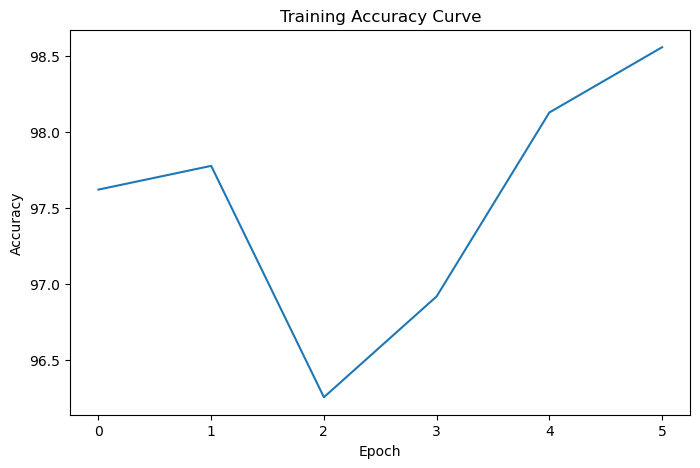

In [35]:
plt.figure(figsize=(8,5))
plt.plot(train_acc_history)
plt.title("Training Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.savefig(
    "outputs/training_accuracy_curve.png"
)
plt.show()

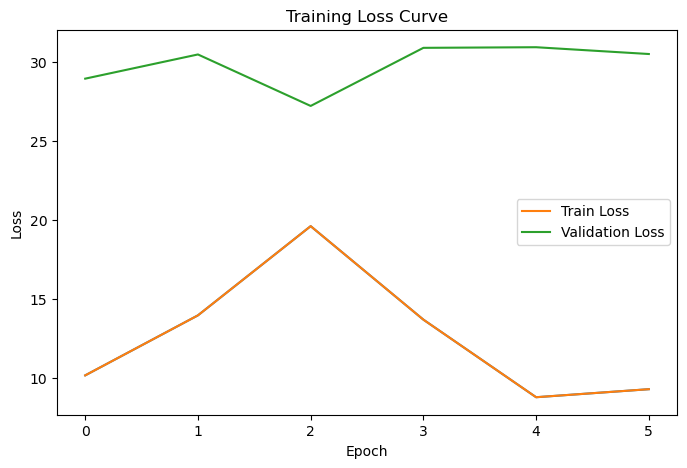

In [36]:
plt.figure(figsize=(8,5))
plt.plot(train_loss_history)
plt.plot(train_loss_history, label='Train Loss')
plt.plot(val_loss_history, label='Validation Loss')
plt.legend()
plt.title("Training Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.savefig(
    "outputs/training_loss_curve.png"
)
plt.show()


In [41]:
# =========================================================
# MODEL EVALUATION
# =========================================================

y_true = []
y_pred = []
y_prob = []
model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        probabilities = torch.softmax(outputs, dim=1)
        _, preds = torch.max(outputs, 1)
        y_true.extend(labels.numpy())
        y_pred.extend(preds.cpu().numpy())
        y_prob.extend(probabilities.cpu().numpy())

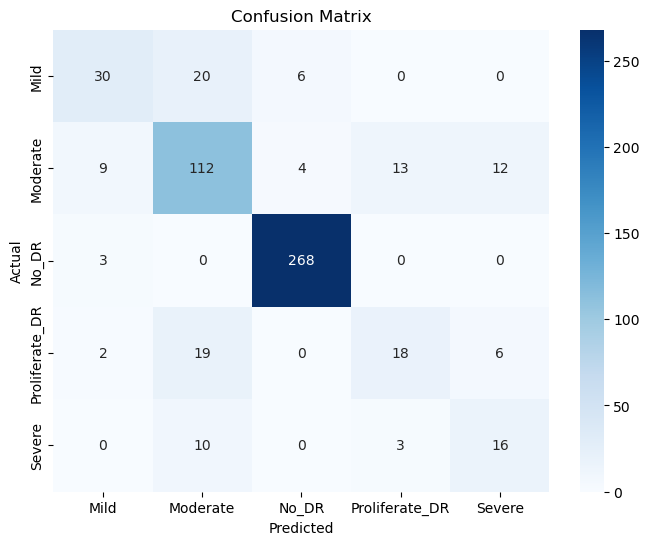

In [38]:
cm = confusion_matrix(
    y_true,
    y_pred
)
plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=classes,
    yticklabels=classes
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig(
    "outputs/confusion_matrix.png"
)
plt.show()

In [39]:
report = classification_report(
    y_true,
    y_pred,
    target_names=classes
)
print(report)

with open(
    "outputs/classification_report.txt",
    "w"
) as f:

    f.write(report)


                precision    recall  f1-score   support

          Mild       0.68      0.54      0.60        56
      Moderate       0.70      0.75      0.72       150
         No_DR       0.96      0.99      0.98       271
Proliferate_DR       0.53      0.40      0.46        45
        Severe       0.47      0.55      0.51        29

      accuracy                           0.81       551
     macro avg       0.67      0.64      0.65       551
  weighted avg       0.80      0.81      0.80       551



ROC-AUC Curve


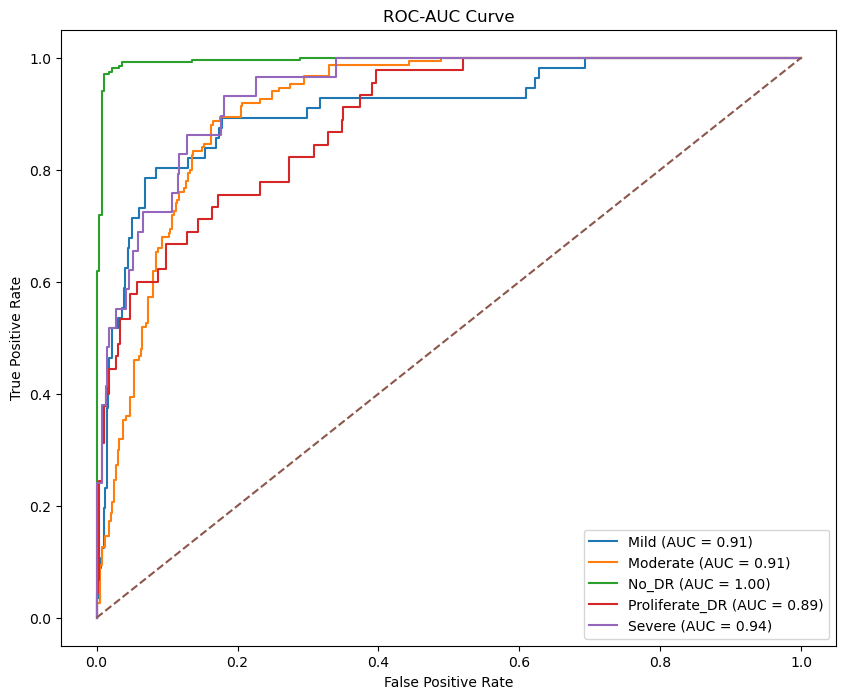

In [42]:
print("ROC-AUC Curve")
# =========================================================
# ROC-AUC CURVE
# =========================================================

y_true_bin = label_binarize(
    y_true,
    classes=[0,1,2,3,4]
)

y_prob = np.array(y_prob)

plt.figure(figsize=(10,8))

for i in range(len(classes)):

    fpr, tpr, _ = roc_curve(
        y_true_bin[:, i],
        y_prob[:, i]
    )

    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        label=f"{classes[i]} (AUC = {roc_auc:.2f})"
    )

plt.plot(
    [0,1],
    [0,1],
    linestyle='--'
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC-AUC Curve")

plt.legend()

plt.savefig(
    "outputs/roc_auc.png"
)

plt.show()

In [ ]:
print("GradCAM Analysis")


In [ ]:
print(
    "EfficientNetV2 Training Completed Successfully"
)

In [45]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from torchvision.transforms.functional import to_pil_image

model.load_state_dict(
    torch.load(
        "best_efficientnetv2_model.pth"
    )
)
model.eval()

target_layer = model.conv_head
cam = GradCAM(
    model=model,
    target_layers=[target_layer]
)

# =========================================================
# GRADCAM ANALYSIS
# =========================================================

correct_count = 0
wrong_count = 0
for images, labels in test_loader:
    images = images.to(device)
    labels = labels.to(device)
    outputs = model(images)
    _, preds = torch.max(outputs, 1)

    for i in range(len(images)):
        image_tensor = images[i].unsqueeze(0)
        grayscale_cam = cam(
            input_tensor=image_tensor
        )[0]
        rgb_img = images[i].cpu().permute(1,2,0).numpy()
        rgb_img = (
            rgb_img - rgb_img.min()
        ) / (
            rgb_img.max() - rgb_img.min()
        )
        visualization = show_cam_on_image(
            rgb_img,
            grayscale_cam,
            use_rgb=True
        )
       
       
        # CORRECT PREDICTIONS
        if preds[i] == labels[i]:
            save_path = (
                f"outputs/gradcam/correct/"
                f"correct_{correct_count}.png"
            )
            plt.imsave(
                save_path,
                visualization
            )

            correct_count += 1


        # WRONG PREDICTIONS
        else:
            save_path = (
                f"outputs/gradcam/wrong/"
                f"wrong_{wrong_count}.png"
            )
            plt.imsave(
                save_path,
                visualization
            )

            wrong_count += 1
            
print("GradCAM Images Saved")


GradCAM Images Saved


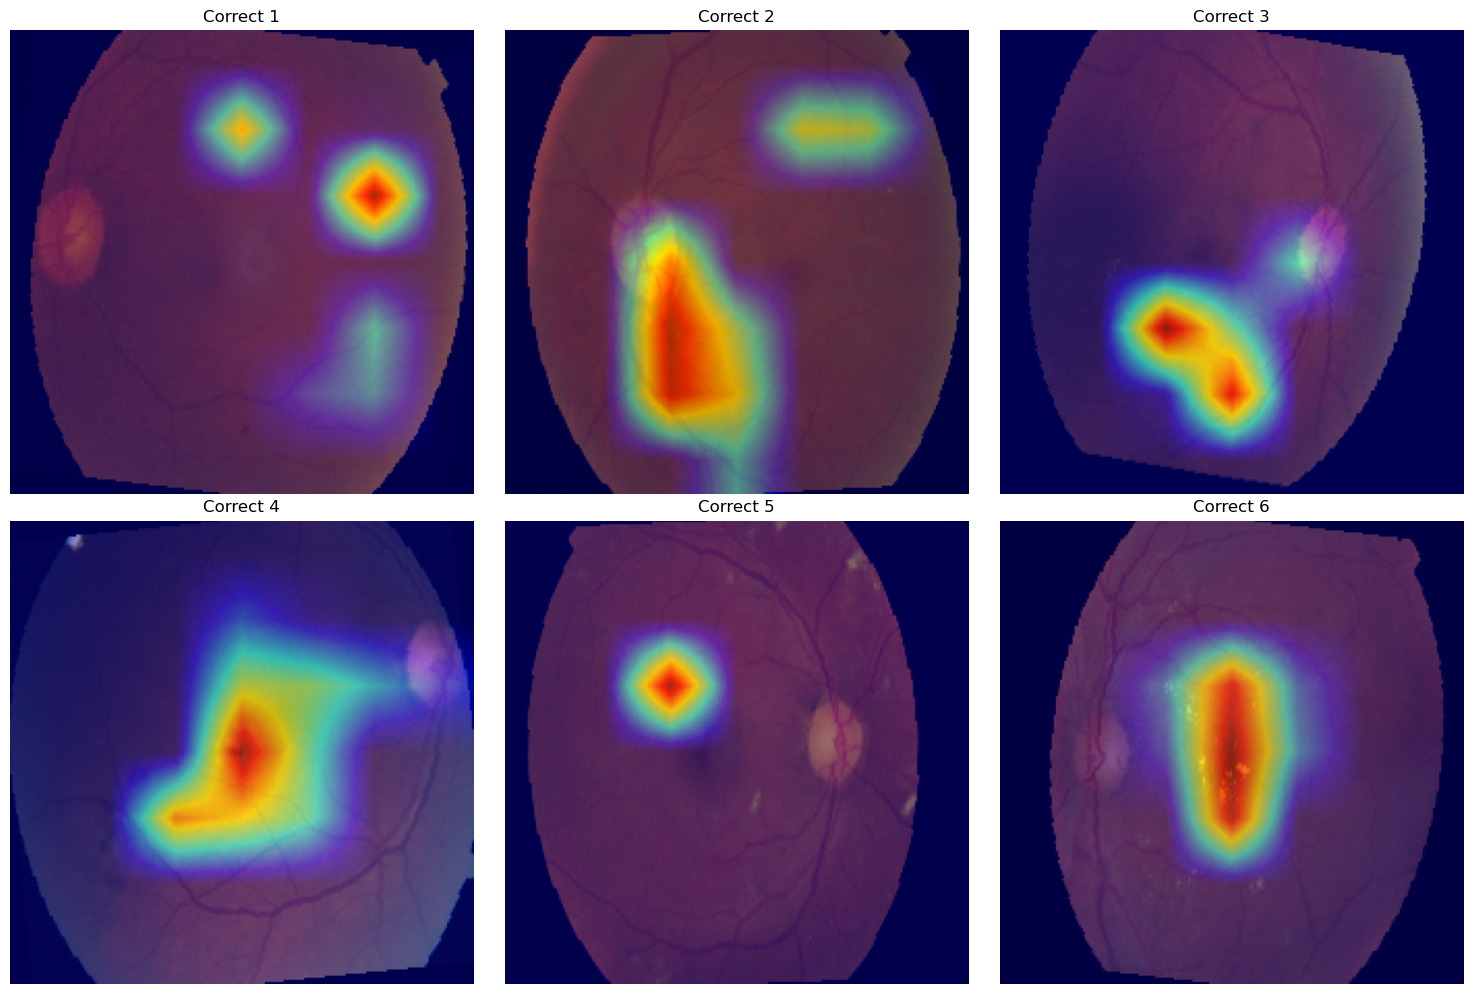

In [46]:
# =========================================================
# DISPLAY CORRECT GRADCAM IMAGES
# =========================================================

import glob
from PIL import Image
correct_images = glob.glob(
    "outputs/gradcam/correct/*.png"
)
plt.figure(figsize=(15,10))
for i, img_path in enumerate(correct_images[:6]):

    img = Image.open(img_path)

    plt.subplot(2,3,i+1)

    plt.imshow(img)

    plt.axis("off")

    plt.title(f"Correct {i+1}")

plt.tight_layout()

plt.show()

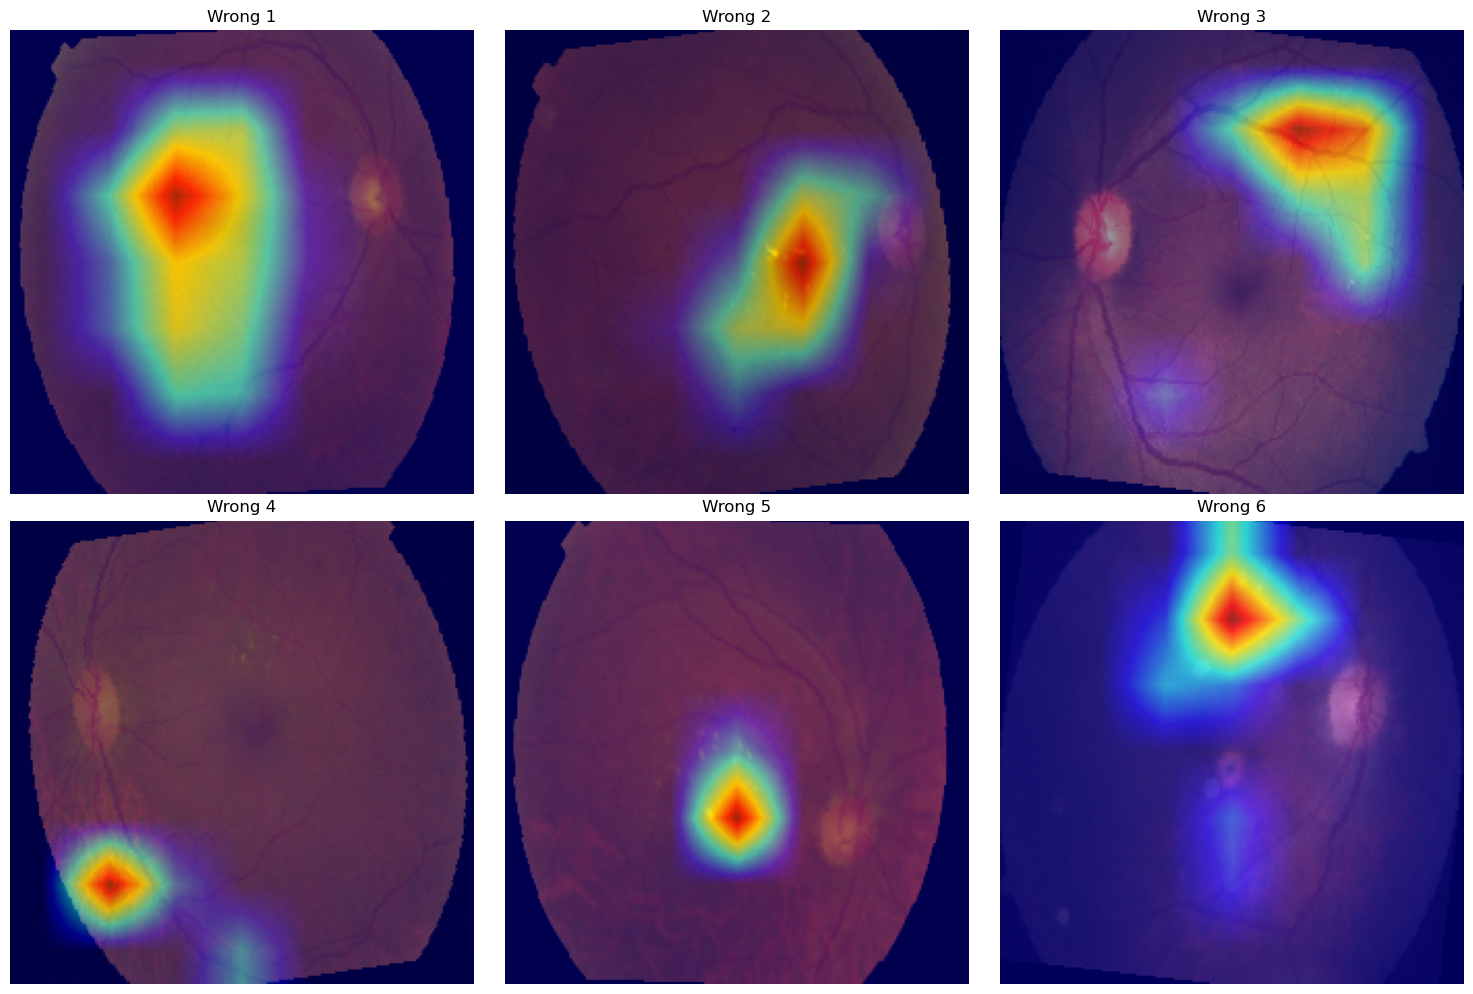

In [47]:
# =========================================================
# DISPLAY WRONG GRADCAM IMAGES
# =========================================================

wrong_images = glob.glob(
    "outputs/gradcam/wrong/*.png"
)

plt.figure(figsize=(15,10))

for i, img_path in enumerate(wrong_images[:6]):

    img = Image.open(img_path)

    plt.subplot(2,3,i+1)

    plt.imshow(img)

    plt.axis("off")

    plt.title(f"Wrong {i+1}")

plt.tight_layout()

plt.show()